# Email Spam Detection using Machine Learning

## Oasis Infobyte Data Science Internship

### Objective

The objective of this project is to build a Natural Language Processing (NLP) model capable of classifying SMS messages as **Spam** or **Ham (Not Spam)**.

### Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- NLTK
- WordCloud

### Developed By

**Haseeb Ur Rehman**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import string
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Load Dataset

The SMS Spam Collection dataset contains text messages labeled as either **Spam** or **Ham**. This dataset will be used to train and evaluate machine learning models for spam detection.

In [6]:
df = pd.read_csv('/content/spam.csv', encoding='latin1')

## Dataset Overview

This dataset contains SMS messages labeled as either **Spam** or **Ham**. The goal is to build a machine learning model capable of automatically identifying unwanted spam messages.

In [7]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Dataset Information

This section provides information about the dataset structure, column names, data types, and non-null values.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


## Dataset Shape

The shape of the dataset indicates the total number of rows and columns available for analysis.

In [9]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 5572
Columns : 5


## Missing Value Analysis

Before preprocessing, it is important to identify missing values that may affect model performance.

In [10]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


## Duplicate Records

Duplicate messages are identified to ensure data quality before training the models.

In [11]:
df.duplicated().sum()

np.int64(403)

## Data Cleaning

The dataset contains unnecessary empty columns. These columns are removed, and the remaining columns are renamed to meaningful names for easier analysis.

In [12]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

df.columns = ["Label", "Message"]

df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Cleaned Dataset

The dataset now contains only two essential columns:

- Label
- Message

In [15]:
df.isnull().sum()

,0
Label,0
Message,0


In [16]:
df = df.drop_duplicates()

df.shape

(5169, 2)

## Class Distribution

The distribution of Spam and Ham messages is analyzed to understand whether the dataset is balanced or imbalanced before model training.

In [17]:
df["Label"].value_counts()

,count
Label,
ham,4516
spam,653


In [18]:
round(df["Label"].value_counts(normalize=True) * 100, 2)

,proportion
Label,
ham,87.37
spam,12.63


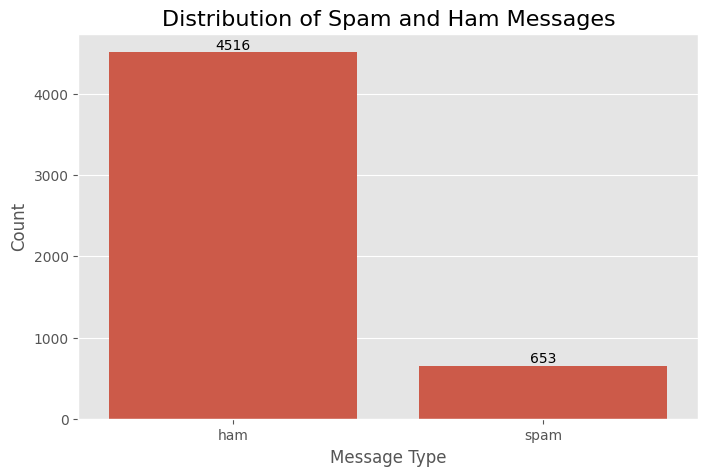

In [19]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x="Label")

plt.title("Distribution of Spam and Ham Messages", fontsize=16)
plt.xlabel("Message Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Text Preprocessing

Raw text cannot be used directly for machine learning. Therefore, the following preprocessing steps are applied:

- Convert text to lowercase
- Remove punctuation
- Remove numbers
- Remove stopwords
- Apply stemming

These steps improve the quality of text features and help the model achieve better performance.

In [20]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words("english"))

In [21]:
def preprocess_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [stemmer.stem(word) for word in words]

    return " ".join(words)

In [22]:
df["Processed_Message"] = df["Message"].apply(preprocess_text)

df.head()

,Label,Message,Processed_Message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


## Original vs Processed Messages

The table below compares the original messages with the cleaned and preprocessed messages.

In [23]:
df[["Message","Processed_Message"]].head(10)

,Message,Processed_Message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl week word back id like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request mell mell oru minnaminungint nurun...
8,WINNER!! As a valued network customer you have...,winner valu network custom select receivea pri...
9,Had your mobile 11 months or more? U R entitle...,mobil month u r entitl updat latest colour mob...


## Message Length Analysis

The number of characters in each message is calculated to analyze the length distribution of spam and ham messages.

In [24]:
df["Message_Length"] = df["Message"].apply(len)

df.head()

,Label,Message,Processed_Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...,111
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...,155
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though,61


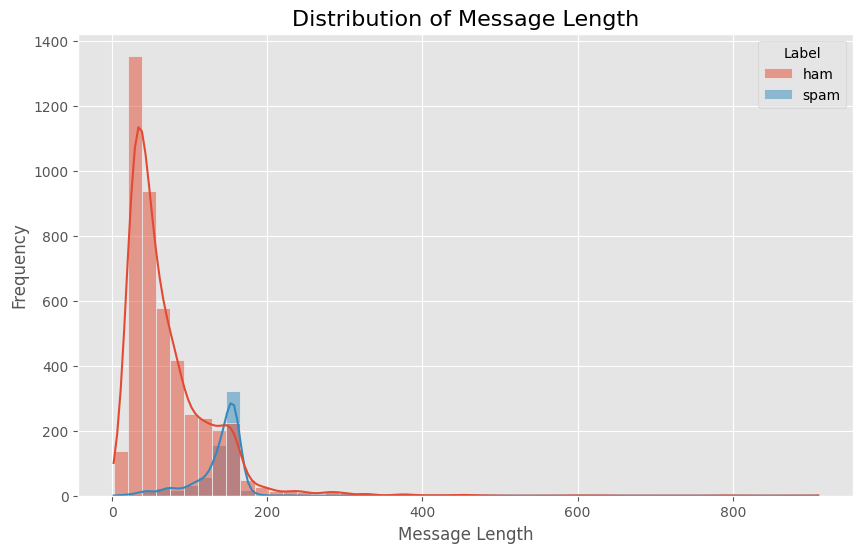

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Message_Length",
    hue="Label",
    bins=50,
    kde=True
)

plt.title("Distribution of Message Length", fontsize=16)

plt.xlabel("Message Length")

plt.ylabel("Frequency")

plt.show()

## WordCloud Visualization

WordCloud is a visual representation of the most frequently occurring words in the dataset.

Separate WordClouds are generated for Spam and Ham messages to understand the dominant words in each category.

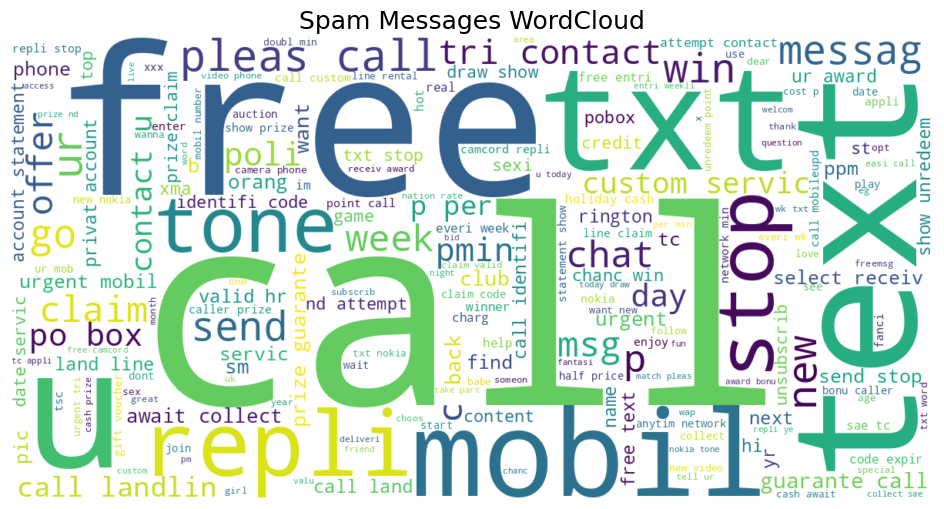

In [26]:
spam_words = " ".join(df[df["Label"] == "spam"]["Processed_Message"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(spam_words)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Spam Messages WordCloud", fontsize=18)

plt.show()

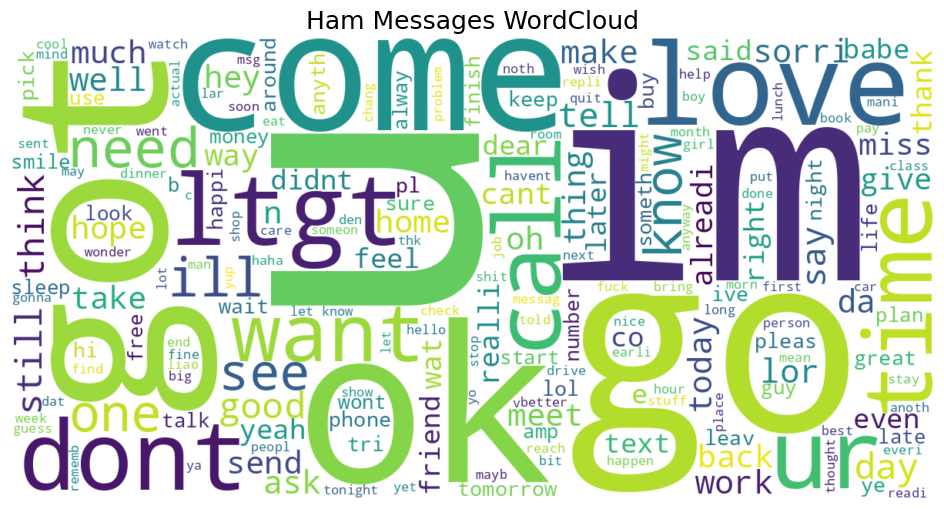

In [27]:
ham_words = " ".join(df[df["Label"] == "ham"]["Processed_Message"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(ham_words)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Ham Messages WordCloud", fontsize=18)

plt.show()

## Most Frequent Spam Words

The following chart shows the most frequently occurring words in spam messages after preprocessing.

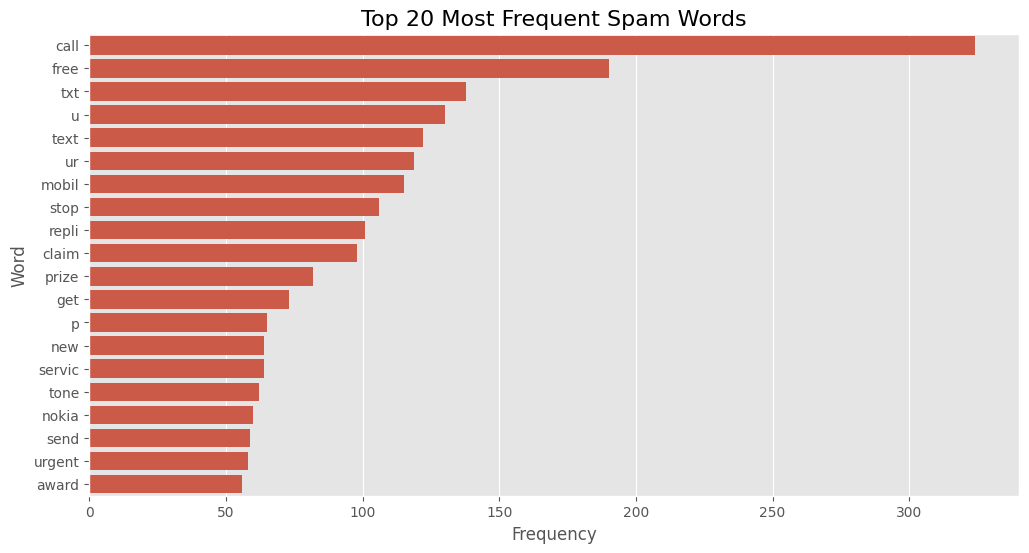

In [28]:
from collections import Counter

spam_text = " ".join(df[df["Label"]=="spam"]["Processed_Message"])

spam_counter = Counter(spam_text.split())

spam_df = pd.DataFrame(
    spam_counter.most_common(20),
    columns=["Word","Frequency"]
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=spam_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Frequent Spam Words", fontsize=16)

plt.show()

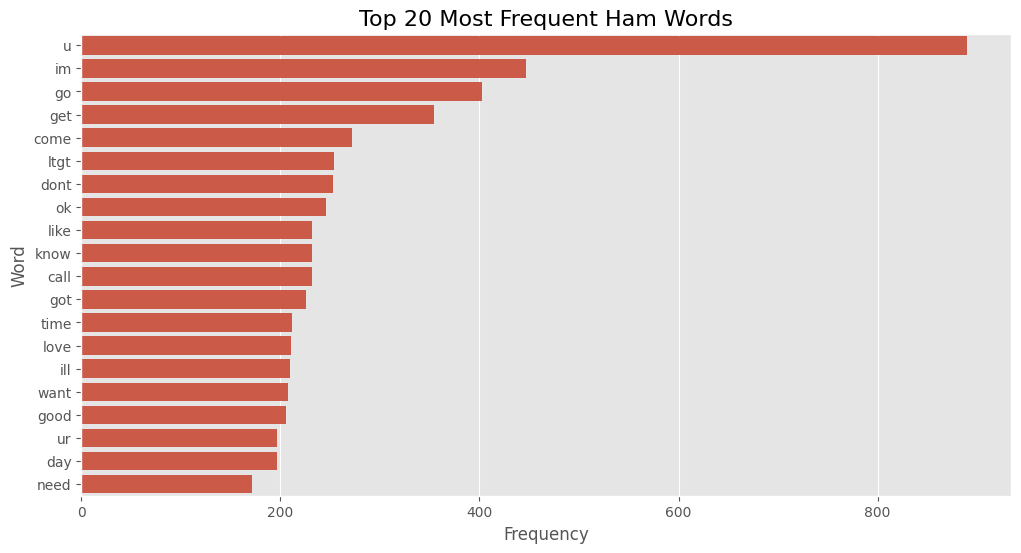

In [29]:
ham_text = " ".join(df[df["Label"]=="ham"]["Processed_Message"])

ham_counter = Counter(ham_text.split())

ham_df = pd.DataFrame(
    ham_counter.most_common(20),
    columns=["Word","Frequency"]
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=ham_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Frequent Ham Words", fontsize=16)

plt.show()

# TF-IDF Vectorization

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical feature vectors.

- **Term Frequency (TF):** Measures how often a word appears in a document.
- **Inverse Document Frequency (IDF):** Reduces the importance of very common words appearing across many documents.

This technique helps machine learning algorithms focus on the most informative words.

In [30]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Processed_Message"])

y = df["Label"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4135, 5000)
(1034, 5000)


# Model 1 — Multinomial Naive Bayes

Multinomial Naive Bayes is one of the most widely used machine learning algorithms for text classification tasks. It performs exceptionally well on TF-IDF features and is considered an industry-standard baseline for spam detection.

In [32]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_prediction = nb_model.predict(X_test)

In [33]:
nb_accuracy = accuracy_score(y_test, nb_prediction)

nb_precision = precision_score(y_test, nb_prediction, pos_label="spam")

nb_recall = recall_score(y_test, nb_prediction, pos_label="spam")

nb_f1 = f1_score(y_test, nb_prediction, pos_label="spam")

print("Accuracy :", round(nb_accuracy,4))
print("Precision :", round(nb_precision,4))
print("Recall :", round(nb_recall,4))
print("F1 Score :", round(nb_f1,4))

Accuracy : 0.9681
Precision : 0.99
Recall : 0.7557
F1 Score : 0.8571


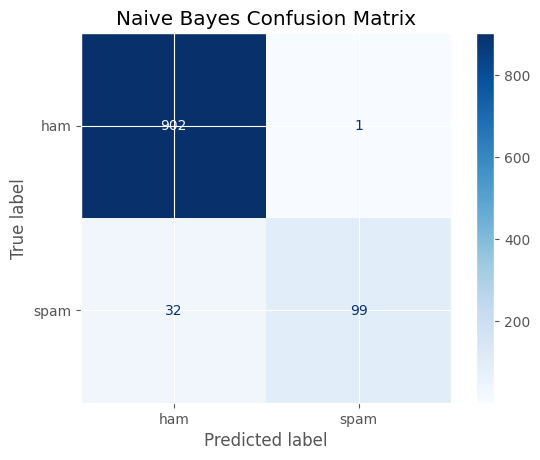

In [34]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_prediction,
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [35]:
print(classification_report(y_test, nb_prediction))

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       903
        spam       0.99      0.76      0.86       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034



# Model 2 — Logistic Regression

Logistic Regression is a powerful linear classification algorithm that performs well on high-dimensional text data. It serves as an excellent comparison model against Multinomial Naive Bayes.

In [36]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

In [37]:
lr_accuracy = accuracy_score(y_test, lr_prediction)

lr_precision = precision_score(y_test, lr_prediction, pos_label="spam")

lr_recall = recall_score(y_test, lr_prediction, pos_label="spam")

lr_f1 = f1_score(y_test, lr_prediction, pos_label="spam")

print("Accuracy :", round(lr_accuracy,4))
print("Precision :", round(lr_precision,4))
print("Recall :", round(lr_recall,4))
print("F1 Score :", round(lr_f1,4))

Accuracy : 0.9555
Precision : 1.0
Recall : 0.6489
F1 Score : 0.787


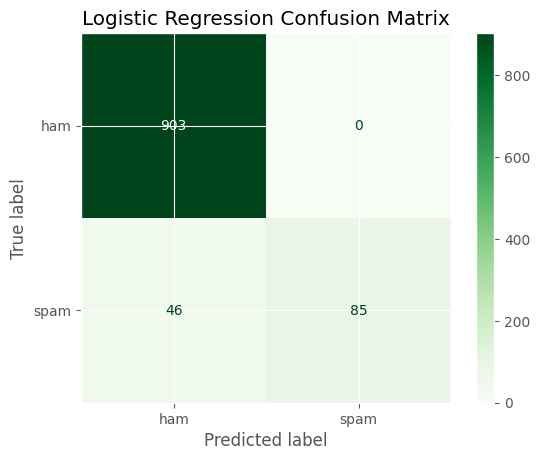

In [38]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_prediction,
    cmap="Greens"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [39]:
print(classification_report(y_test, lr_prediction))

              precision    recall  f1-score   support

         ham       0.95      1.00      0.98       903
        spam       1.00      0.65      0.79       131

    accuracy                           0.96      1034
   macro avg       0.98      0.82      0.88      1034
weighted avg       0.96      0.96      0.95      1034



# Model Comparison

Both machine learning models are compared using multiple evaluation metrics including Accuracy, Precision, Recall, and F1 Score to identify the best-performing classifier.

In [40]:
comparison = pd.DataFrame({

    "Model":[
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy":[
        nb_accuracy,
        lr_accuracy
    ],

    "Precision":[
        nb_precision,
        lr_precision
    ],

    "Recall":[
        nb_recall,
        lr_recall
    ],

    "F1 Score":[
        nb_f1,
        lr_f1
    ]

})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.9681,0.99,0.7557,0.8571
1,Logistic Regression,0.9555,1.00,0.6489,0.7870


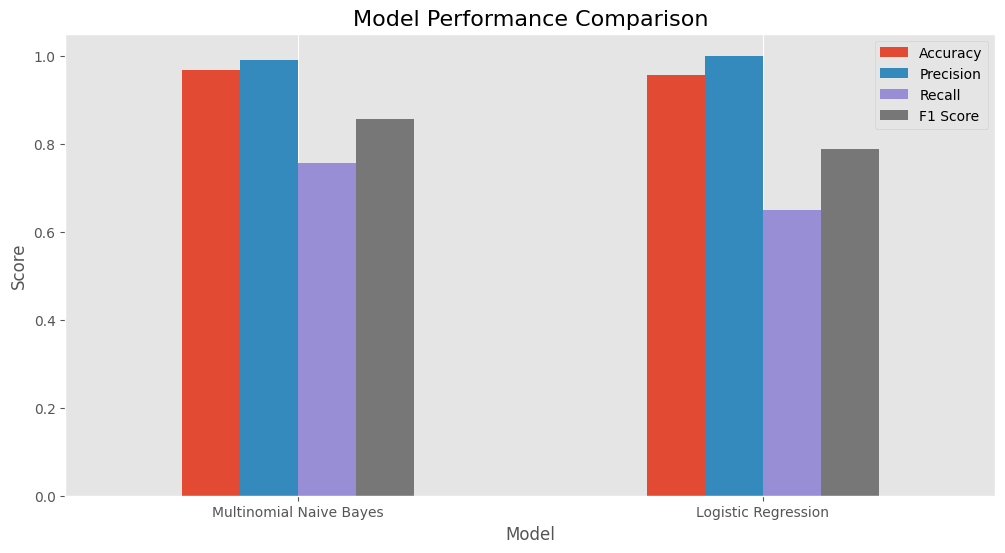

In [41]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Model Performance Comparison", fontsize=16)

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

# Best Performing Model

The best-performing model is selected based on Accuracy, Precision, Recall, and F1 Score.

Although both models perform well, the final model is selected according to its overall classification performance on unseen data.

In [42]:
best_model = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

best_model.head(1)

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.9681,0.99,0.7557,0.8571


# Custom Message Prediction

The trained model can classify completely new SMS messages as either Spam or Ham.

In [43]:
def predict_message(message):

    processed = preprocess_text(message)

    vector = tfidf.transform([processed])

    prediction = lr_model.predict(vector)[0]

    print("Message")
    print(message)

    print()

    print("Prediction :", prediction.upper())

In [44]:
predict_message(

"""
Congratulations!

You have won a FREE iPhone.

Click the link now to claim your prize.
"""

)

Message

Congratulations!

You have won a FREE iPhone.

Click the link now to claim your prize.


Prediction : SPAM


In [45]:
predict_message(

"""
Hi Haseeb,

Are we still meeting tomorrow for the machine learning project discussion?

"""

)

Message

Hi Haseeb,

Are we still meeting tomorrow for the machine learning project discussion?



Prediction : HAM


# Why is Recall Important in Spam Detection?

Recall measures the ability of the model to correctly identify spam messages.

A high recall is essential because failing to detect spam means unwanted or potentially harmful messages may reach users. In real-world email and SMS filtering systems, minimizing false negatives is often more important than minimizing false positives, making recall one of the most critical evaluation metrics.

# ROC Curve

The Receiver Operating Characteristic (ROC) Curve illustrates the classification performance of the model across different decision thresholds.

The Area Under the Curve (AUC) indicates how well the model distinguishes between Spam and Ham messages.

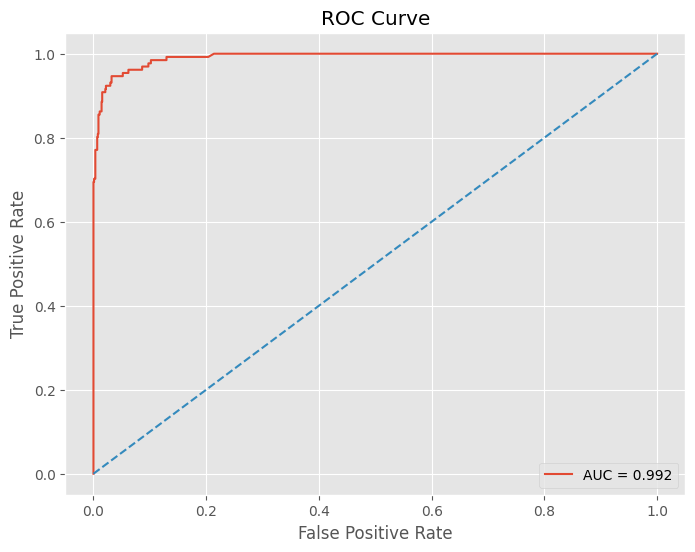

In [46]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc

encoder = LabelEncoder()

y_test_binary = encoder.fit_transform(y_test)

lr_probabilities = lr_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test_binary,
    lr_probabilities
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [47]:
def predict_with_probability(message):

    processed = preprocess_text(message)

    vector = tfidf.transform([processed])

    prediction = lr_model.predict(vector)[0]

    probability = lr_model.predict_proba(vector).max()

    print("="*60)

    print("Message")

    print(message)

    print()

    print("Prediction :", prediction.upper())

    print("Confidence :", round(probability*100,2),"%")

    print("="*60)

In [48]:
predict_with_probability(

"""
Congratulations!

You have won a FREE vacation.

Claim your reward now.

"""

)

Message

Congratulations!

You have won a FREE vacation.

Claim your reward now.



Prediction : SPAM
Confidence : 72.4 %


In [49]:
messages = [

"Congratulations! You won a free iPhone.",

"Meeting starts tomorrow at 9 AM.",

"Your account has been suspended. Click here.",

"Can you send me today's notes?"

]

for msg in messages:

    predict_with_probability(msg)

    print()

Message
Congratulations! You won a free iPhone.

Prediction : HAM
Confidence : 73.49 %

Message
Meeting starts tomorrow at 9 AM.

Prediction : HAM
Confidence : 95.52 %

Message
Your account has been suspended. Click here.

Prediction : HAM
Confidence : 83.36 %

Message
Can you send me today's notes?

Prediction : HAM
Confidence : 88.46 %



In [50]:
comparison.style\
.background_gradient(cmap="Greens")\
.format("{:.4f}",subset=["Accuracy","Precision","Recall","F1 Score"])

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.9681,0.9900,0.7557,0.8571
1,Logistic Regression,0.9555,1.0000,0.6489,0.7870


# Project Summary

This section summarizes the overall project, including dataset statistics, model performance, and the final selected model.

In [52]:
print("=" * 60)

print("EMAIL SPAM DETECTION PROJECT SUMMARY")

print("=" * 60)

print()

print("Dataset Shape :", df.shape)

print()

print("Best Performing Model")

display(best_model)

print()

print("Spam Messages :", len(df[df["Label"] == "spam"]))

print("Ham Messages :", len(df[df["Label"] == "ham"]))

print()

print("ROC AUC Score :", round(roc_auc, 4))

print()

print("=" * 60)

EMAIL SPAM DETECTION PROJECT SUMMARY

Dataset Shape : (5169, 4)

Best Performing Model


,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.9681,0.99,0.7557,0.8571
1,Logistic Regression,0.9555,1.00,0.6489,0.7870



Spam Messages : 653
Ham Messages : 4516

ROC AUC Score : 0.9916



# Future Improvements

Although the current machine learning models achieved excellent performance, the project can be further enhanced by:

- Deploying the model using Streamlit or Flask.
- Integrating real-time email classification.
- Using advanced NLP models such as BERT.
- Building a REST API for prediction.
- Deploying the application on cloud platforms.

In [57]:
message = input("Enter your message: ")

processed = preprocess_text(message)

vector = tfidf.transform([processed])

prediction = lr_model.predict(vector)[0]

probability = lr_model.predict_proba(vector).max()

print()

print("Prediction :", prediction.upper())

print("Confidence :", f"{probability*100:.2f}%")

Enter your message: hi haseeb you have win iphone 12 please click the link

Prediction : HAM
Confidence : 70.57%


In [54]:
samples = [
    "Congratulations! You have won a free iPhone.",
    "Can we meet tomorrow at 10 AM?",
    "Claim your lottery prize now.",
    "Please send me the project report."
]

for message in samples:
    predict_with_probability(message)
    print()

Message
Congratulations! You have won a free iPhone.

Prediction : HAM
Confidence : 73.49 %

Message
Can we meet tomorrow at 10 AM?

Prediction : HAM
Confidence : 96.61 %

Message
Claim your lottery prize now.

Prediction : SPAM
Confidence : 86.44 %

Message
Please send me the project report.

Prediction : HAM
Confidence : 86.52 %



In [55]:
messages = [
    "Free recharge available.",
    "Meeting at 5 PM.",
    "Win cash now.",
    "Project presentation tomorrow."
]

predictions = []

for msg in messages:

    processed = preprocess_text(msg)

    vector = tfidf.transform([processed])

    pred = lr_model.predict(vector)[0]

    prob = lr_model.predict_proba(vector).max()

    predictions.append([
        msg,
        pred,
        round(prob*100,2)
    ])

prediction_df = pd.DataFrame(
    predictions,
    columns=[
        "Message",
        "Prediction",
        "Confidence (%)"
    ]
)

prediction_df

,Message,Prediction,Confidence (%)
0,Free recharge available.,ham,82.53
1,Meeting at 5 PM.,ham,94.67
2,Win cash now.,spam,63.92
3,Project presentation tomorrow.,ham,94.96


# Thank You

Thank you for reviewing this project.

This project was developed as part of the **Oasis Infobyte Data Science Internship** and demonstrates the practical application of Natural Language Processing (NLP) and Machine Learning for spam message classification.

**Developed by**

**Haseeb Ur Rehman**